# GNN Energy Prediction — Ensemble Uncertainty on A
Train the GNN multiple times per geometry configuration to quantify the uncertainty on the stochastic resolution parameter A in `RMSE/E = A/sqrt(E)`.

In [2]:
import pandas as pd
import os
os.environ["DGLBACKEND"] = "pytorch"
import dgl
import torch
from dgl.data import DGLDataset
import matplotlib.pyplot as plot
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from dgl.nn import GraphConv, SumPooling, GINConv, AvgPooling, MaxPooling
from dgl.dataloading import GraphDataLoader
from tqdm import tqdm
from datetime import datetime
from torch.utils.data.sampler import SubsetRandomSampler
from scipy.optimize import curve_fit
from GNN_util import (
    process_df_vectorized, create_directory, HitDataset,
    create_fast_edge_lists, GIN, train_GNN, test_GNN,
    calculate_bin_rmse, get_text_positions, get_min_max_of_graph_dataset
)

current_date = datetime.now().strftime("%B_%d")

In [3]:
class GNN_model_saver:
    def __init__(self, model, test_truths, test_preds, bin_centers, rmse, rmse_unc, rel_rmse, rel_rmse_unc, bin_min, bin_max):
        self.model = model
        self.test_truths = test_truths
        self.test_preds = test_preds
        self.bin_centers = bin_centers
        self.rmse = rmse
        self.rmse_unc = rmse_unc
        self.rel_rmse = rel_rmse
        self.rel_rmse_unc = rel_rmse_unc
        self.bin_min = bin_min
        self.bin_max = bin_max

def calculate_bin_rmse_w_unc(test_dataloader, model, bin_width=0.5, bin_min=1.0, bin_max=3.0, B=1000):
    bin_centers = np.arange(bin_min.item() + bin_width / 2, bin_max.item(), bin_width)
    summed_sqe_per_bin = {bc: 0.0 for bc in bin_centers}
    sqe_per_bin_arr = {bc: [] for bc in bin_centers}
    bin_counts = {bc: 0 for bc in bin_centers}
    preds = []
    truths = []
    with torch.no_grad():
        for batched_graph, labels in test_dataloader:
            graphs = dgl.unbatch(batched_graph)
            for i in range(len(graphs)):
                graph = graphs[i]
                labels_w_event_feats = labels[i]
                label = labels_w_event_feats[0].item()
                event_feats = labels_w_event_feats[1:].unsqueeze(0)
                pred = model(graph, graph.ndata["feat"].float(), event_feats).detach().numpy()
                preds.append(pred)
                truths.append(label)
                squared_error = (pred - label) ** 2
                for bin_center in bin_centers:
                    bin_min_edge = bin_center - bin_width / 2
                    bin_max_edge = bin_center + bin_width / 2
                    if bin_min_edge <= label < bin_max_edge:
                        summed_sqe_per_bin[bin_center] += squared_error
                        bin_counts[bin_center] += 1
                        sqe_per_bin_arr[bin_center].append(squared_error)
                        break
    rmse_per_bin = {}
    rmse_unc_per_bin = {}
    for bin_center in bin_centers:
        if bin_counts[bin_center] > 0:
            rmse_value = np.sqrt(summed_sqe_per_bin[bin_center] / bin_counts[bin_center])
            rmse_per_bin[bin_center] = float(rmse_value[0,0])
            rng = np.random.default_rng()
            this_bin_sqe = np.array(sqe_per_bin_arr[bin_center])
            N = len(this_bin_sqe)
            random_indices = rng.integers(low=0, high=N, size=(B, N))
            resampled_sqe = this_bin_sqe[random_indices]
            bootstrapped_rmse_values = np.sqrt(np.mean(resampled_sqe, axis=1))
            rmse_unc_per_bin[bin_center] = np.std(bootstrapped_rmse_values)
        else:
            rmse_per_bin[bin_center] = float('nan')
            rmse_unc_per_bin[bin_center] = 0
        bin_centers = np.array(list(rmse_per_bin.keys()))
        rmse = np.array(list(rmse_per_bin.values()))
        rmse_unc = np.array(list(rmse_unc_per_bin.values()))
        rel_rmse = rmse / bin_centers
        rel_rmse_unc = rmse_unc / bin_centers
    return bin_centers, rmse, rmse_unc, rel_rmse, rel_rmse_unc

In [4]:
def GNN_workflow(data_prefix="baseline_CFD_pixel_threshold_3_March_14_neutron_0_5GeV_to_5GeV500events_run_40_", run_num=40, plot_loss=False):
    data_path = "/hpc/group/vossenlab/rck32/eic/work_eic/macros/Timing_estimation/data/df/"
    num_dfs = 50
    dfs = []
    for i in range(0, 0 + num_dfs):
        try:
            new_df = pd.read_csv(data_path + data_prefix + f"{i}.csv")
        except FileNotFoundError as e:
            print(f"skipping file #{i} with name: {data_path}{data_prefix}{i}.csv")
            continue
        new_df["file_idx"] = i
        dfs.append(new_df)
    if len(dfs) > 1:
        data = pd.concat(dfs)
    else:
        data = dfs[0]
    modified_df = process_df_vectorized(data, cone_angle_deg=40)
    dataset = HitDataset(modified_df, True, connection_mode="kNN", k=6)
    num_layers = run_num_to_layer[run_num]
    print(f"Starting dataset with n_layers = {num_layers}")

    train_frac = 0.7
    val_frac = 0.15
    num_train = int(np.floor(len(dataset) * train_frac))
    num_val = int(np.floor(len(dataset) * val_frac))
    num_examples = len(dataset)

    train_sampler = SubsetRandomSampler(torch.arange(num_train))
    val_sampler = SubsetRandomSampler(torch.arange(num_train, num_val + num_train))
    test_sampler = SubsetRandomSampler(torch.arange(num_val + num_train, num_examples))

    train_dataloader = GraphDataLoader(dataset, sampler=train_sampler, batch_size=20, drop_last=False)
    val_dataloader = GraphDataLoader(dataset, sampler=val_sampler, batch_size=20, drop_last=False)
    test_dataloader = GraphDataLoader(dataset, sampler=test_sampler, batch_size=20, drop_last=False)

    hidden_dim = 32
    linear_capacity = 5
    early_stopping_limit = 4
    n_conv_layers = 2
    n_linear_layers = 7
    lr = 1e-4
    model = GIN(dataset.dim_nfeats, hidden_dim, dataset.dim_event_feats,
                n_conv_layers=n_conv_layers, n_linear_layers=n_linear_layers, linear_capacity=linear_capacity)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model_path = f"/hpc/group/vossenlab/rck32/eic/work_eic/macros/Timing_estimation/models/{current_date}/energy_only/"
    n_epochs = 300
    trained_model, train_losses, val_losses, optimizer, best_epoch = train_GNN(
        model, optimizer, criterion, train_dataloader, val_dataloader, n_epochs, early_stopping_limit, model_path=model_path
    )
    if plot_loss:
        plot.plot(train_losses, label="train")
        plot.title("Train and Val loss throughout training (log scale)")
        plot.plot(val_losses, label="test")
        plot.legend()
        plot.tight_layout()
    test_truths, test_preds, test_rmse = test_GNN(trained_model, test_dataloader)
    bin_min, bin_max = get_min_max_of_graph_dataset(dataset)
    bin_centers, rmse, rmse_unc, rel_rmse, rel_rmse_unc = calculate_bin_rmse_w_unc(
        test_dataloader, model, bin_width=0.25, bin_min=bin_min, bin_max=bin_max, B=10000
    )
    return GNN_model_saver(model, test_truths, test_preds, bin_centers, rmse, rmse_unc, rel_rmse, rel_rmse_unc, bin_min, bin_max)

In [5]:
particle = "neutron"
num_layers_vals = [3, 20]
run_num_to_layer = {3: 14, 20: 20, 30: 30, 40: 40}
color_map = {14: 'b', 20: 'r', 30: 'g', 40: 'y'}
N_ensemble = 5

## Run ensemble training
Train the GNN `N_ensemble` times for each layer configuration. Store the per-bin RMSE and relative RMSE from each run.

In [6]:
# Dictionary: n_layers -> list of GNN_model_saver results
ensemble_results = {}

for val in num_layers_vals:
    n_layers = run_num_to_layer[val]
    ensemble_results[n_layers] = []
    prefix = f"baseline_CFD_pixel_threshold_3_March_14_neutron_0_5GeV_to_5GeV500events_run_{val}_"
    for run_i in range(N_ensemble):
        print(f"\n===== {n_layers} layers, run {run_i + 1}/{N_ensemble} =====")
        result = GNN_workflow(data_prefix=prefix, run_num=val)
        ensemble_results[n_layers].append(result)
        print(f"  RMSE mean: {np.mean(result.rmse):.4f}")


===== 14 layers, run 1/5 =====
Starting dataset with n_layers = 14
Epoch 1/300 - Train loss:	 1.2857
Epoch 1/300 - Validation MSE:	 0.5529

Epoch 2/300 - Train loss:	 0.5130
Epoch 2/300 - Validation MSE:	 0.4583

Epoch 3/300 - Train loss:	 0.4656
Epoch 3/300 - Validation MSE:	 0.4428

Epoch 4/300 - Train loss:	 0.4417
Epoch 4/300 - Validation MSE:	 0.4180

Epoch 5/300 - Train loss:	 0.4228
Epoch 5/300 - Validation MSE:	 0.4109

Epoch 6/300 - Train loss:	 0.4173
Epoch 6/300 - Validation MSE:	 0.3980

Epoch 7/300 - Train loss:	 0.4106
Epoch 7/300 - Validation MSE:	 0.3998

Test loss increased, adding uptick
Epoch 8/300 - Train loss:	 0.3988
Epoch 8/300 - Validation MSE:	 0.4053

Test loss increased, adding uptick
Epoch 9/300 - Train loss:	 0.4030
Epoch 9/300 - Validation MSE:	 0.3749

Epoch 10/300 - Train loss:	 0.3942
Epoch 10/300 - Validation MSE:	 0.3826

Test loss increased, adding uptick
Epoch 11/300 - Train loss:	 0.3880
Epoch 11/300 - Validation MSE:	 0.3751

Test loss increased,

## Aggregate ensemble results
For each bin, compute the mean and std of RMSE and relative RMSE across the ensemble runs. Then fit `A/sqrt(E)` to the averaged relative RMSE with the ensemble std as the uncertainty.

In [7]:
def func(x, A):
    return A / np.sqrt(x)

# Store aggregated quantities per layer config
ensemble_summary = {}

for n_layers, results in ensemble_results.items():
    # Stack per-bin arrays from each run (all runs share the same bin_centers)
    bin_centers = results[0].bin_centers
    all_rmse = np.array([r.rmse for r in results])           # shape (N_ensemble, n_bins)
    all_rel_rmse = np.array([r.rel_rmse for r in results])   # shape (N_ensemble, n_bins)

    # Mean and std across ensemble runs for each bin
    mean_rmse = np.mean(all_rmse, axis=0)
    std_rmse = np.std(all_rmse, axis=0)
    mean_rel_rmse = np.mean(all_rel_rmse, axis=0)
    std_rel_rmse = np.std(all_rel_rmse, axis=0)

    # Fit A/sqrt(E) to the ensemble-averaged relative RMSE
    # Use the ensemble std as the uncertainty on each bin
    params, cov = curve_fit(func, bin_centers, mean_rel_rmse, sigma=std_rel_rmse, absolute_sigma=True)
    A = params[0]
    A_fit_unc = np.sqrt(cov[0, 0])

    # Also collect A from each individual run's fit
    A_per_run = []
    for r in results:
        p, _ = curve_fit(func, r.bin_centers, r.rel_rmse, sigma=r.rel_rmse_unc, absolute_sigma=True)
        A_per_run.append(p[0])
    A_per_run = np.array(A_per_run)

    # Chi-squared of the averaged fit
    y_fit_binned = func(bin_centers, A)
    chi2 = np.sum(((mean_rel_rmse - y_fit_binned) / std_rel_rmse) ** 2)
    ndof = len(bin_centers) - 1
    red_chi2 = chi2 / ndof

    ensemble_summary[n_layers] = {
        'bin_centers': bin_centers,
        'mean_rmse': mean_rmse,
        'std_rmse': std_rmse,
        'mean_rel_rmse': mean_rel_rmse,
        'std_rel_rmse': std_rel_rmse,
        'A': A,
        'A_fit_unc': A_fit_unc,
        'A_per_run': A_per_run,
        'A_ensemble_mean': np.mean(A_per_run),
        'A_ensemble_std': np.std(A_per_run),
        'red_chi2': red_chi2,
        'bin_min': results[0].bin_min,
        'bin_max': results[0].bin_max,
    }

    print(f"\n--- {n_layers} layers ---")
    print(f"  A (fit to ensemble mean):  {A:.4f} +/- {A_fit_unc:.4f}")
    print(f"  A (mean of per-run fits):  {np.mean(A_per_run):.4f} +/- {np.std(A_per_run):.4f}")
    print(f"  Individual A values:       {A_per_run}")
    print(f"  Reduced chi-squared:       {red_chi2:.3f}")


--- 14 layers ---
  A (fit to ensemble mean):  0.4033 +/- 0.0007
  A (mean of per-run fits):  0.3487 +/- 0.0067
  Individual A values:       [0.34705549 0.34815839 0.35056797 0.33836819 0.35927824]
  Reduced chi-squared:       128.008

--- 20 layers ---
  A (fit to ensemble mean):  0.3511 +/- 0.0011
  A (mean of per-run fits):  0.3258 +/- 0.0041
  Individual A values:       [0.32690268 0.33230546 0.32237682 0.32065579 0.32689588]
  Reduced chi-squared:       21.570


## Comparison plots
Plot the ensemble-averaged RMSE, relative RMSE with A/sqrt(E) fits, and pred-vs-true for both layer configurations side by side.

Saved plot.


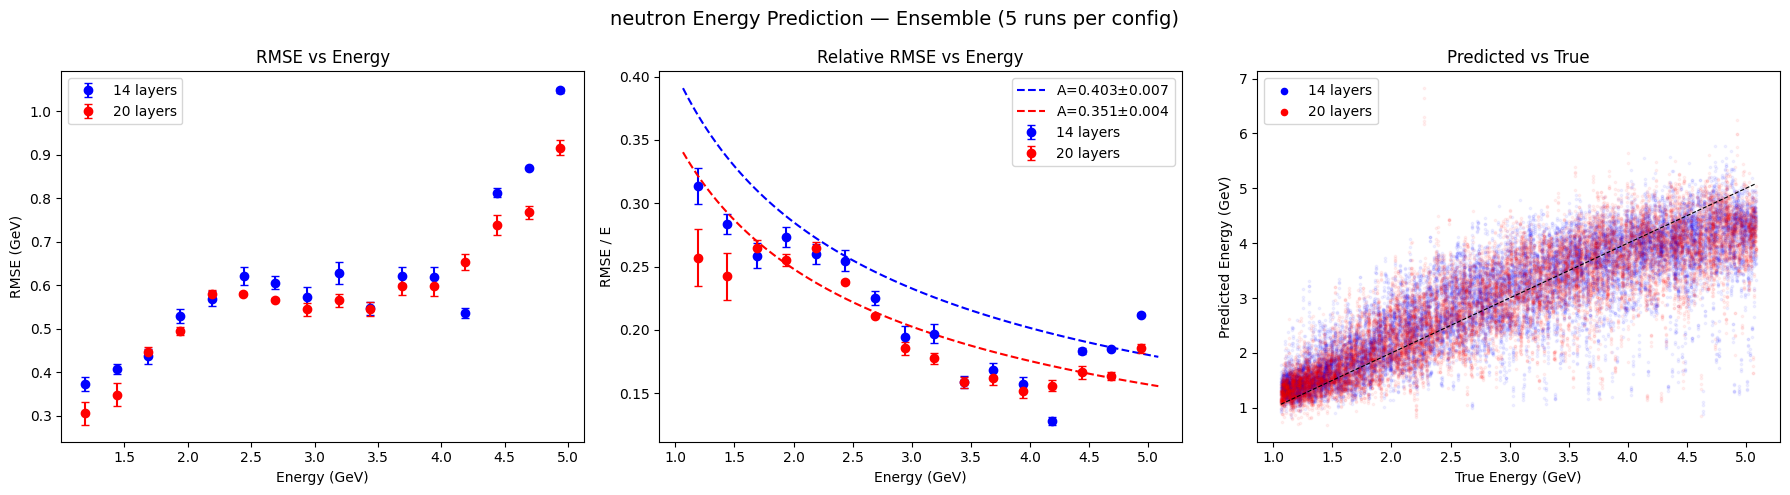

In [8]:
fig, axs = plot.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"{particle} Energy Prediction — Ensemble ({N_ensemble} runs per config)", fontsize=14)

for n_layers, s in ensemble_summary.items():
    color = color_map[n_layers]
    bc = s['bin_centers']

    # RMSE vs E
    axs[0].errorbar(bc, s['mean_rmse'], yerr=s['std_rmse'], fmt='o', color=color,
                    label=f"{n_layers} layers", capsize=3)
    axs[0].set(xlabel="Energy (GeV)", ylabel="RMSE (GeV)", title="RMSE vs Energy")

    # Relative RMSE vs E with fit
    axs[1].errorbar(bc, s['mean_rel_rmse'], yerr=s['std_rel_rmse'], fmt='o', color=color,
                    label=f"{n_layers} layers", capsize=3)
    x_fit = np.linspace(s['bin_min'].item(), s['bin_max'].item(), 100)
    y_fit = func(x_fit, s['A'])
    axs[1].plot(x_fit, y_fit, '--', color=color,
               label=f"A={s['A']:.3f}$\\pm${s['A_ensemble_std']:.3f}")
    axs[1].set(xlabel="Energy (GeV)", ylabel="RMSE / E", title="Relative RMSE vs Energy")

    # Pred vs True (overlay all ensemble runs)
    for r in ensemble_results[n_layers]:
        axs[2].scatter(r.test_truths, r.test_preds, alpha=0.05, s=3, color=color)
    # Dummy point for legend
    axs[2].scatter([], [], color=color, label=f"{n_layers} layers", s=20)

# Identity line on pred vs true
all_mins = [s['bin_min'].item() for s in ensemble_summary.values()]
all_maxs = [s['bin_max'].item() for s in ensemble_summary.values()]
lims = [min(all_mins), max(all_maxs)]
axs[2].plot(lims, lims, 'k--', linewidth=0.8)
axs[2].set(xlabel="True Energy (GeV)", ylabel="Predicted Energy (GeV)", title="Predicted vs True")

for ax in axs:
    ax.legend()
fig.tight_layout()
# fig.savefig(f"plots/GNN_results/{particle}_ensemble_{N_ensemble}runs_comparison.pdf")
print("Saved plot.")

## Summary table

In [9]:
print(f"{'Layers':<10} {'A (ensemble mean ± std)':<30} {'A (fit ± fit_unc)':<30} {'Red. chi2':<12}")
print("-" * 82)
for n_layers, s in ensemble_summary.items():
    print(f"{n_layers:<10} {s['A_ensemble_mean']:.4f} +/- {s['A_ensemble_std']:.4f}          "
          f"{s['A']:.4f} +/- {s['A_fit_unc']:.4f}          {s['red_chi2']:.3f}")

Layers     A (ensemble mean ± std)        A (fit ± fit_unc)              Red. chi2   
----------------------------------------------------------------------------------
14         0.3487 +/- 0.0067          0.4033 +/- 0.0007          128.008
20         0.3258 +/- 0.0041          0.3511 +/- 0.0011          21.570
